In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import seaborn as sns
sns.set_theme()

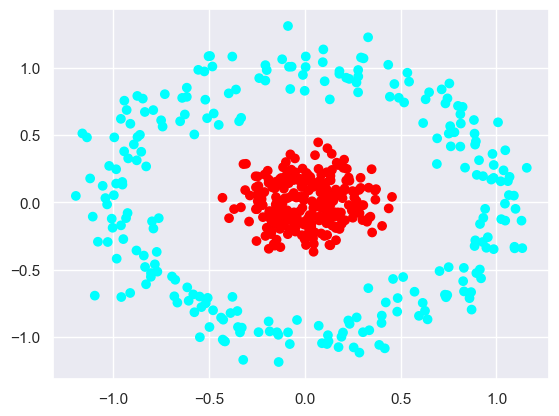

In [214]:
X, y=make_circles(n_samples=500, noise=0.1, random_state=42, factor=0.2)
y=2*y-1
X_train, X_test, y_train, y_test=train_test_split(X, y, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y+2, cmap=colors.ListedColormap(['cyan', 'red']));

In [215]:
def plot_decision_boundary(model, X, y, ax=None, alpha=1, plot_points=True):
    if ax is None:
        ax=plt.axes()
    points_x=np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    points_y=np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
    mesh=np.meshgrid(points_x, points_y)
    df=pd.DataFrame(np.column_stack((mesh[0].flatten(), mesh[1].flatten())))
    
    predictions=model.predict(df)
    ax.scatter(df[0], df[1], s=5, marker='.', c=predictions+2, 
               cmap=colors.ListedColormap(['blue', 'yellow']), alpha=alpha)
    if plot_points:
        ax.scatter(X[:, 0], X[:, 1], c=y+2, cmap=colors.ListedColormap(['cyan', 'orange']), edgecolors='k')

    return ax
    


In [167]:
class AdaBoost(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator, learning_rate=0.5, n_estimators=10, random_state=0):
        self.estimator=estimator # the learner that will be used
        self.learning_rate=learning_rate # the learning rate that will be used
        self.n_estimators=n_estimators # the number of max estimators to add in the ensemble
        self.actual_iterations=0 # actual iterations took to fit the model
        self.estimators=[]  # the list of trained estimators
        self.weights=[] # alphas weight of each estimator
        self.random_state=random_state
        self._is_fitted=False

    def calc_error(self, y_true, y_pred, distribution):
        return ((y_true != y_pred)*distribution).sum()
    
    def calc_weight(self, error):
        if error==0:
            return 10
        elif error>=0.5:
            raise ValueError('A weak learner was not encountered.\n Provide a weak learner')
        else:
            return self.learning_rate * np.log2((1-error)/error)
    
    def updated_distribution(self, y_true, y_pred, distribution, new_alpha):
        un_normalised=np.exp((-new_alpha)*y_true*y_pred)*distribution
        return un_normalised/un_normalised.sum()


    def fit(self, X, y):
        n=X.shape[0]
        self.estimators=[]
        self.weights=[]
        self.actual_iterations=0
        distribution=np.array([1/n]*n)

        for i in range(self.n_estimators):
            new_estimator=clone(self.estimator)
            new_estimator.fit(X, y, sample_weight=distribution)
            predictions=new_estimator.predict(X)
            error=self.calc_error(y, predictions, distribution)
            new_alpha=self.calc_weight(error)

            self.estimators.append(new_estimator)
            self.weights.append(new_alpha)
            self.actual_iterations+=1
            
            if error==0:
                break
            
            distribution=self.updated_distribution(y, predictions, distribution, new_alpha)

        self._is_fitted=True
        return self
    
    def predict(self, X):
        ensemble_predictions=np.zeros(X.shape[0])
        for i in range(self.actual_iterations):
            ensemble_predictions+=self.weights[i]*self.estimators[i].predict(X)
        
        positive=(ensemble_predictions>=0)
        ensemble_predictions[positive]=1
        ensemble_predictions[~positive]=-1
        return ensemble_predictions
    
    def plot_decision_boundary_pair(self, X, y, alpha=1):
        fig, axes=plt.subplots(ncols=2)
        for i in range(self.actual_iterations):
            points=False
            if i==self.actual_iterations-1:
                points=True
            plot_decision_boundary(self.estimators[i], X, y, ax=axes[0],
                                   alpha=alpha, plot_points=points)
        plot_decision_boundary(self, X, y, ax=axes[1], alpha=alpha)
        return fig, axes
            

    def __sklearn_is_fitted__(self):
        return self._is_fitted

In [20]:
a=np.arange(10)
a.sum()

np.int64(45)

In [21]:
log_reg=LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [22]:
log_reg.score(X_train, y_train)

0.328

In [77]:
clsf=AdaBoost(log_reg, n_estimators=5)
clsf.fit(X_train, y_train)

ValueError: A weak learner was not encountered.
 Provide a weak learner

In [94]:
dt=DecisionTreeClassifier(max_depth=1)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=1)

In [95]:
dt.score(X_train, y_train)

0.6933333333333334

In [96]:
dt.score(X_test, y_test)

0.712

<Axes: >

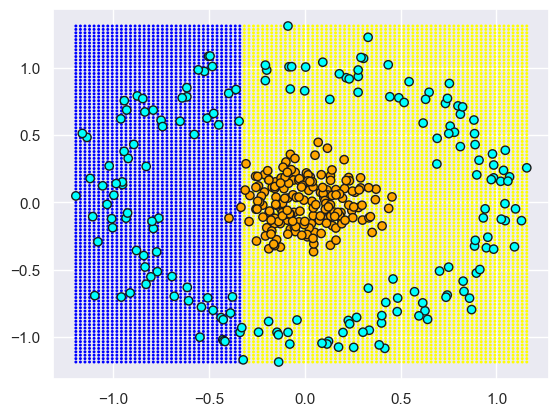

In [216]:
plot_decision_boundary(dt, X_train, y_train)

In [168]:
clsf=AdaBoost(dt, n_estimators=250)
clsf.fit(X_train, y_train)

AdaBoost(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=250)

In [169]:
clsf.actual_iterations

250

In [170]:
predictions=clsf.predict(X_train)
(predictions==y_train).mean()

np.float64(1.0)

In [171]:
predictions=clsf.predict(X_test)
(predictions==y_test).mean()

np.float64(0.992)

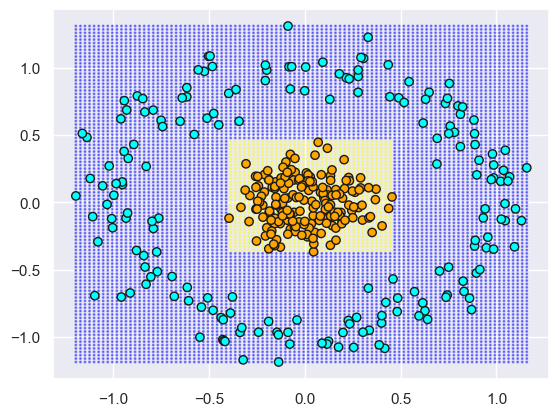

In [217]:
ax=plot_decision_boundary(clsf, X_train, y_train, alpha=0.4)

In [218]:
plot_decision_boundary(dt, X_train, y_train, ax, alpha=0.2, plot_points=False)

<Axes: >

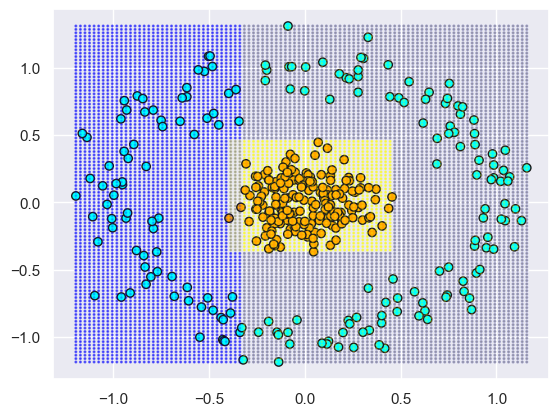

In [219]:
ax.get_figure()

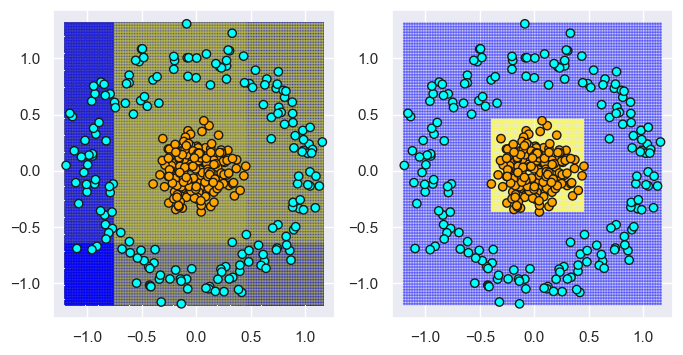

In [220]:
fig, axes=clsf.plot_decision_boundary_pair(X_train, y_train, alpha=0.4)
fig.set_size_inches(8, 4)

In [231]:
clsf=AdaBoost(dt, n_estimators=100, learning_rate=0.6)
clsf.fit(X_train, y_train)

AdaBoost(estimator=DecisionTreeClassifier(max_depth=1), learning_rate=0.6,
         n_estimators=100)

In [232]:
predictions=clsf.predict(X_train)
(predictions==y_train).mean()

np.float64(1.0)

In [233]:
predictions=clsf.predict(X_test)
(predictions==y_test).mean()

np.float64(0.992)

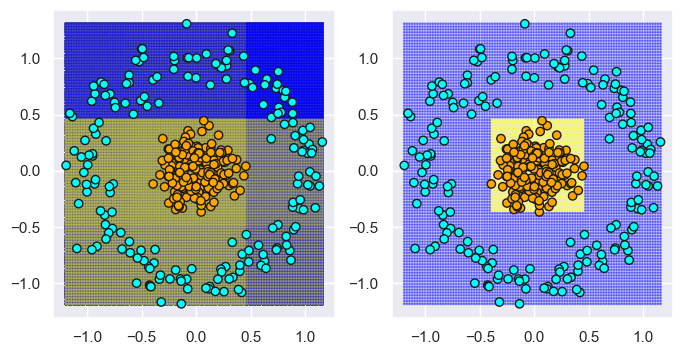

In [234]:
fig, axes=clsf.plot_decision_boundary_pair(X_train, y_train, alpha=0.4)
fig.set_size_inches(8, 4)